# EDAノートブック

本ノートブックは、分析業務で使うEDAを固定手順で実行するための定型版です。
可視化結果は相対パスで `reports/figures` に保存します。


## 固定EDA計画
1. データ読み込みと基本確認
2. 列型・記述統計の確認
3. 欠損率の集計と可視化
4. 数値列の分布確認
5. カテゴリ列の主要分布確認
6. 目的変数の分布と偏り確認
7. 数値特徴量の相関確認
8. 日付列の時系列傾向確認（存在時）
9. 観察結果サマリ


In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")
plt.rcParams["axes.unicode_minus"] = False

JP_FONT_CANDIDATES = [
    "Yu Gothic",
    "Meiryo",
    "MS Gothic",
    "Noto Sans CJK JP",
    "IPAexGothic",
    "IPAGothic",
    "TakaoGothic",
]


def configure_japanese_font() -> str:
    available = {f.name for f in fm.fontManager.ttflist}
    for name in JP_FONT_CANDIDATES:
        if name in available:
            plt.rcParams["font.family"] = name
            return name
    plt.rcParams["font.sans-serif"] = JP_FONT_CANDIDATES + list(plt.rcParams.get("font.sans-serif", []))
    return ""


selected_font = configure_japanese_font()
if selected_font:
    print(f"日本語フォント: {selected_font}")
else:
    print("日本語フォント候補が見つからないため、既定フォントで描画します。")

ENCODINGS = ("utf-8-sig", "utf-8", "cp932", "shift_jis", "euc_jp")

cwd = Path.cwd()
if (cwd / "configs" / "project_config.json").exists():
    analysis_root = cwd
elif (cwd.name == "notebooks") and (cwd.parent / "configs" / "project_config.json").exists():
    analysis_root = cwd.parent
elif (cwd / "artifacts" / "analysis_project" / "configs" / "project_config.json").exists():
    analysis_root = cwd / "artifacts" / "analysis_project"
else:
    analysis_root = cwd

FIG_DIR = analysis_root / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_csv_auto(path: Path):
    sep = "	" if path.suffix.lower() == ".tsv" else ","
    for enc in ENCODINGS:
        try:
            return pd.read_csv(path, encoding=enc, sep=sep), enc
        except UnicodeDecodeError:
            continue
    raise RuntimeError("CSVを既知エンコーディングで読み込めませんでした")


def is_pure_day_number_column(series: pd.Series) -> bool:
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    if numeric.empty:
        return False
    if not np.all(np.isclose(numeric, np.round(numeric))):
        return False
    return bool(((numeric >= 1) & (numeric <= 31)).all())


日本語フォント: Yu Gothic


In [2]:
csv_rel = Path("data/train.csv")
candidates = [
    analysis_root / csv_rel,
    Path("data/train.csv"),
    Path("artifacts/analysis_project") / csv_rel,
]
csv_path = next((p for p in candidates if p.exists()), candidates[0])
df, used_encoding = load_csv_auto(csv_path)
target_col = "SALE PRICE"
if target_col not in df.columns:
    target_col = df.columns[-1]
date_col_hint = "TAX CLASS AT TIME OF SALE".strip() or None

print(f"読み込みエンコーディング: {used_encoding}")
print(f"行数: {len(df):,} / 列数: {df.shape[1]:,}")
print(f"目的変数列: {target_col}")
display(df.head(10))


読み込みエンコーディング: utf-8-sig
行数: 37,751 / 列数: 18
目的変数列: SALE PRICE


,id,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,BUILDING CLASS AT PRESENT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE
0,train_00000,3,CROWN HEIGHTS,09 COOPS - WALKUP APARTMENTS,2C,1162,19,C6,11238,0,0,0,0.0,0.0,1920,2,C6,832444
1,train_00001,5,SUNNYSIDE,01 ONE FAMILY DWELLINGS,1,681,242,A2,10301,1,0,1,4774.0,975.0,1945,1,A2,490000
2,train_00002,4,FLUSHING-NORTH,01 ONE FAMILY DWELLINGS,1,4929,7,A1,11358,1,0,1,4387.0,1260.0,1930,1,A1,817500
3,train_00003,3,DOWNTOWN-METROTECH,13 CONDOS - ELEVATOR APARTMENTS,2,2058,1118,R4,11201,1,0,1,0.0,0.0,1800,2,R4,1250000
4,train_00004,4,KEW GARDENS,10 COOPS - ELEVATOR APARTMENTS,2,3335,23,D4,11415,0,0,0,NaN,NaN,1974,2,D4,212000
5,train_00005,4,REGO PARK,02 TWO FAMILY DWELLINGS,1,3159,94,B3,11374,2,0,2,1600.0,1264.0,1935,1,B3,765000
6,train_00006,2,MORRISANIA/LONGWOOD,01 ONE FAMILY DWELLINGS,1,2669,14,A1,10456,1,0,1,1983.0,1686.0,1920,1,A1,430000
7,train_00007,4,ASTORIA,07 RENTALS - WALKUP APARTMENTS,2A,795,54,C3,11105,4,0,4,2500.0,3450.0,1925,2,C3,1545000
8,train_00008,3,PARK SLOPE,09 COOPS - WALKUP APARTMENTS,2,1103,66,C6,11215,0,0,0,0.0,0.0,1900,2,C6,759000
9,train_00009,2,BAYCHESTER,04 TAX CLASS 1 CONDOS,1A,4939,1005,R3,10466,1,0,1,0.0,0.0,2013,1,R3,343746


## 1. データ概要


In [3]:
try:
    import os
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    print('データ概要')
    print(f'行数: {df.shape[0]}')
    print(f'列数: {df.shape[1]}')
    print('\n列一覧')
    print(df.columns.tolist())
    print('\n先頭5行')
    print(df.head())
    print('\nデータ型')
    print(df.dtypes)
    print('\n基本統計量')
    print(df.describe(include='all').T)
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: overview_code: {_eda_exc}")
    dtype_summary = (
        df.dtypes.astype(str)
        .rename("dtype")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    type_counts = dtype_summary["dtype"].value_counts().rename_axis("dtype").reset_index(name="count")
    print("列型サマリ")
    display(type_counts)
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    category_cols = [c for c in df.columns if c not in numeric_cols]
    print(f"数値列数: {len(numeric_cols)} / カテゴリ列数: {len(category_cols)}")
    display(dtype_summary.head(30))


データ概要
行数: 37751
列数: 18

列一覧
['id', 'BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT', 'BLOCK', 'LOT', 'BUILDING CLASS AT PRESENT', 'ZIP CODE', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS', 'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT', 'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE', 'SALE PRICE']

先頭5行
            id  BOROUGH        NEIGHBORHOOD          BUILDING CLASS CATEGORY  \
0  train_00000        3       CROWN HEIGHTS     09 COOPS - WALKUP APARTMENTS   
1  train_00001        5           SUNNYSIDE          01 ONE FAMILY DWELLINGS   
2  train_00002        4      FLUSHING-NORTH          01 ONE FAMILY DWELLINGS   
3  train_00003        3  DOWNTOWN-METROTECH  13 CONDOS - ELEVATOR APARTMENTS   
4  train_00004        4         KEW GARDENS   10 COOPS - ELEVATOR APARTMENTS   

  TAX CLASS AT PRESENT  BLOCK   LOT BUILDING CLASS AT PRESENT  ZIP CODE  \
0                   2C   1162    19                        C6     11238   
1    

                                  count unique                      top  \
id                                37751  37751              train_00000   
BOROUGH                         37751.0    NaN                      NaN   
NEIGHBORHOOD                      37751    251           FLUSHING-NORTH   
BUILDING CLASS CATEGORY           37751     42  01 ONE FAMILY DWELLINGS   
TAX CLASS AT PRESENT              37751     10                        1   
BLOCK                           37751.0    NaN                      NaN   
LOT                             37751.0    NaN                      NaN   
BUILDING CLASS AT PRESENT         37751    123                       D4   
ZIP CODE                        37751.0    NaN                      NaN   
RESIDENTIAL UNITS               37751.0    NaN                      NaN   
COMMERCIAL UNITS                37751.0    NaN                      NaN   
TOTAL UNITS                     37751.0    NaN                      NaN   
LAND SQUARE FEET         

## 2. 欠損分析


欠損集計
                     欠損数     欠損率(%)
GROSS SQUARE FEET  13555  35.906334
LAND SQUARE FEET   13262  35.130195


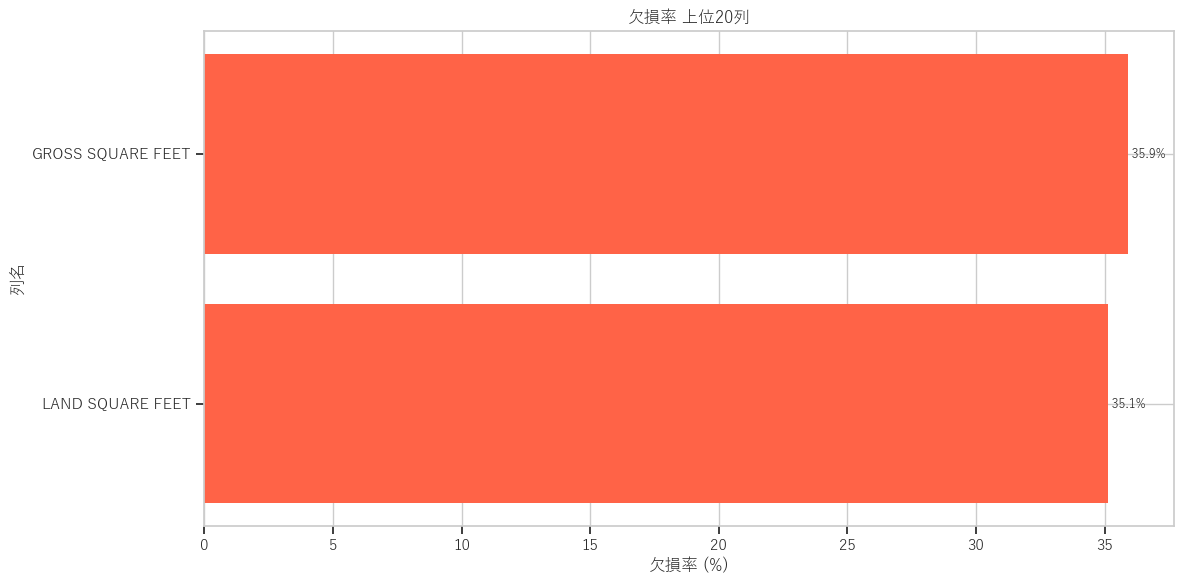

In [4]:
try:
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    missing_count = df.isna().sum().sort_values(ascending=False)
    missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
    missing_df = pd.DataFrame({'欠損数': missing_count, '欠損率(%)': missing_rate})
    missing_df_nonzero = missing_df[missing_df['欠損数'] > 0]
    print('欠損集計')
    print(missing_df_nonzero)

    plt.figure(figsize=(12, 6))
    plot_df = missing_df_nonzero.head(20).sort_values('欠損率(%)', ascending=True)
    if len(plot_df) > 0:
        plt.barh(plot_df.index.astype(str), plot_df['欠損率(%)'], color='tomato')
        plt.xlabel('欠損率 (%)')
        plt.ylabel('列名')
        plt.title('欠損率 上位20列')
        for i, v in enumerate(plot_df['欠損率(%)']):
            plt.text(v, i, f' {v:.1f}%', va='center', fontsize=9)
    else:
        plt.text(0.5, 0.5, '欠損のある列はありません', ha='center', va='center')
        plt.title('欠損率 上位20列')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'missing_rate_top20.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: missing_code: {_eda_exc}")
    missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
    display(missing_rate.rename("欠損率(%)").to_frame().head(20))
    top_missing = missing_rate.head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_missing.plot(kind="bar", ax=ax, color="#4c78a8")
    ax.set_title("欠損率 上位20列")
    ax.set_ylabel("欠損率(%)")
    ax.set_xlabel("列名")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "missing_rate_top20.png", dpi=160, bbox_inches="tight")
    plt.show()


## 3. 数値特徴量の分布


数値列候補
['BOROUGH', 'TAX CLASS AT PRESENT', 'BLOCK', 'LOT', 'ZIP CODE', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS', 'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT', 'TAX CLASS AT TIME OF SALE']


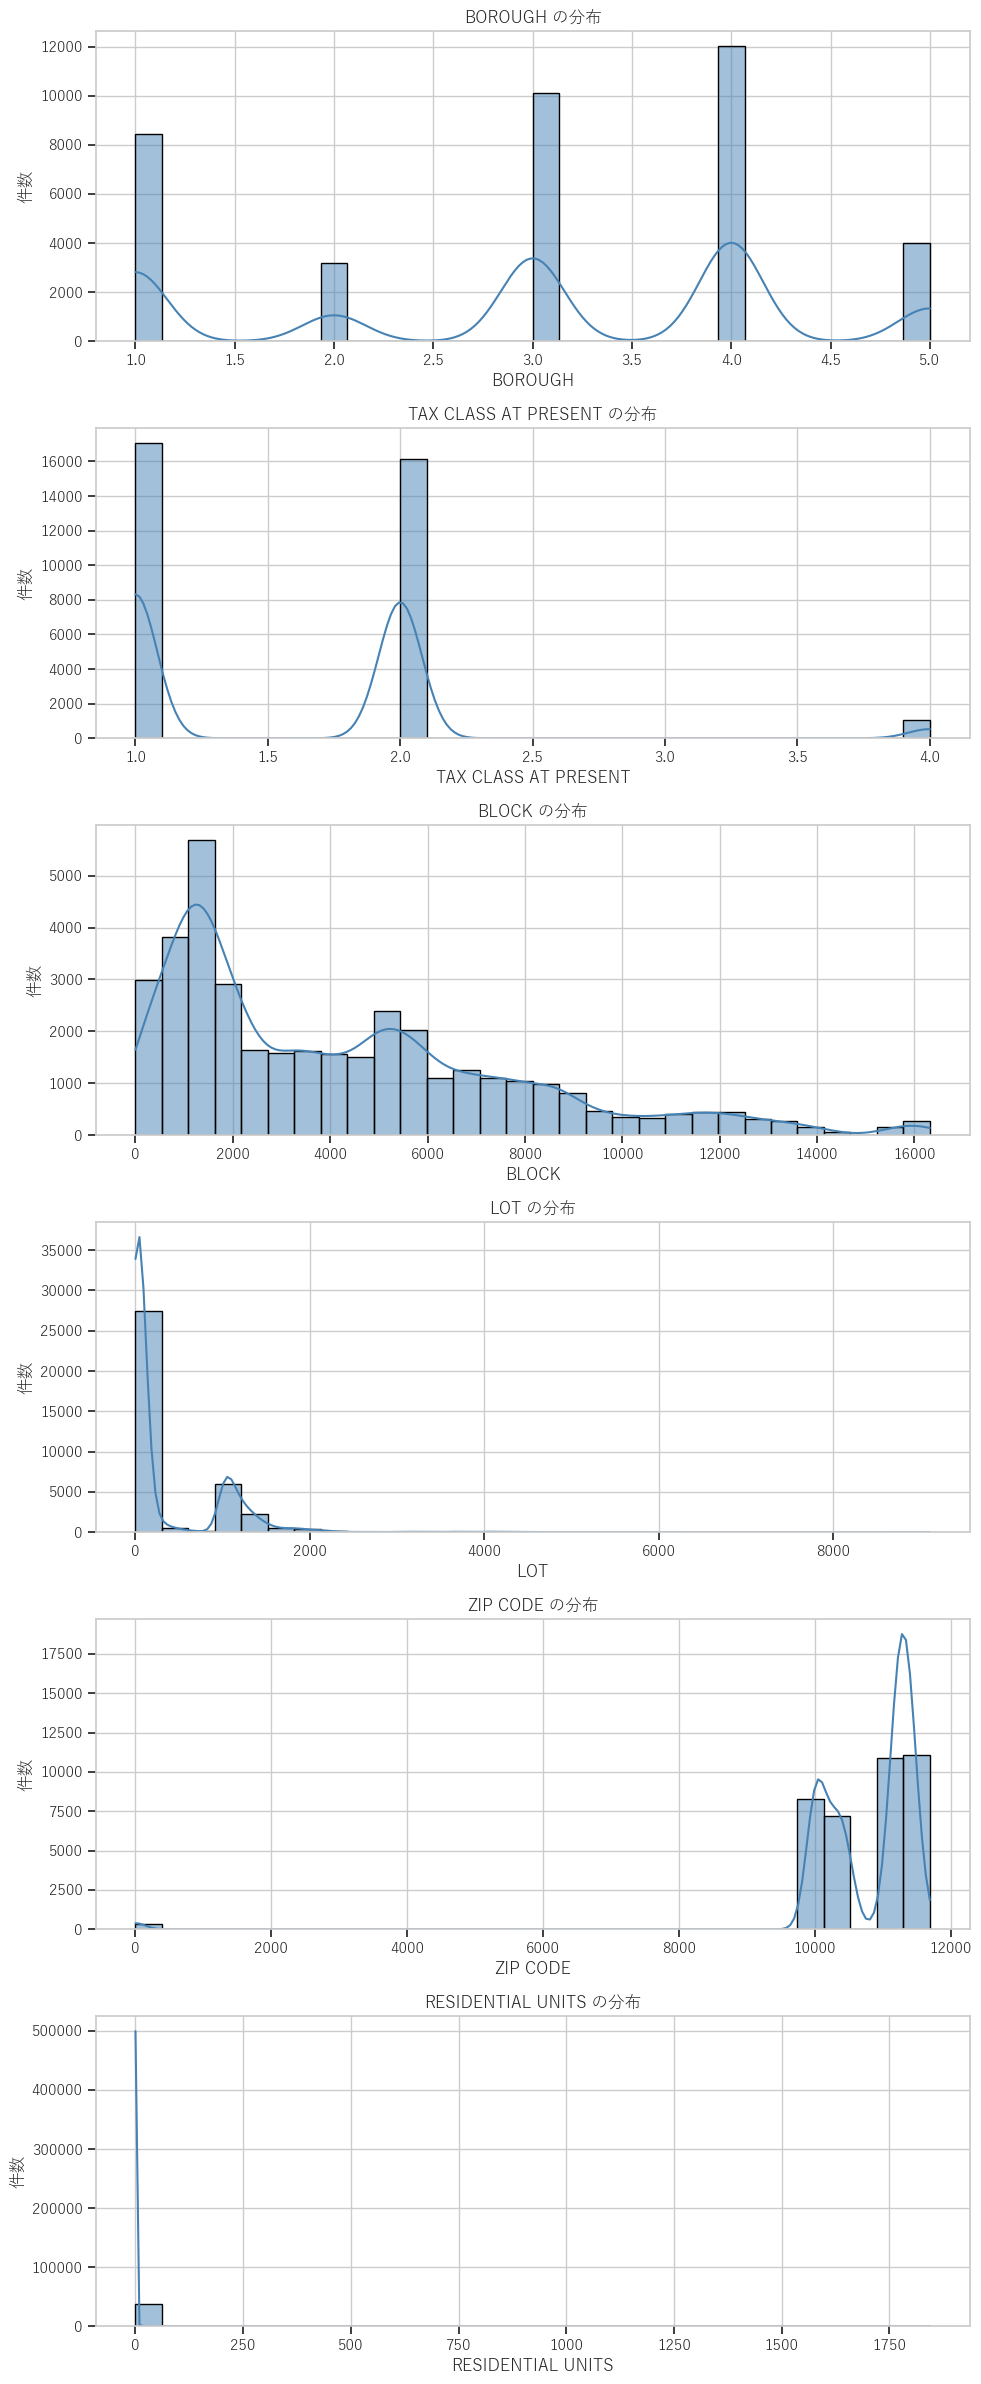

数値列サマリー
                             count          mean           std  min      25%  \
BOROUGH                    37751.0      2.999947      1.311952  1.0      2.0   
TAX CLASS AT PRESENT       34251.0      1.565210      0.659907  1.0      1.0   
BLOCK                      37751.0   4252.686922   3570.966545  1.0   1340.0   
LOT                        37751.0    384.724564    672.798185  1.0     21.0   
ZIP CODE                   37751.0  10741.155731   1197.138941  0.0  10304.0   
RESIDENTIAL UNITS          37751.0      1.247119     10.406437  0.0      0.0   
COMMERCIAL UNITS           37751.0      0.118778     11.663207  0.0      0.0   
TOTAL UNITS                37751.0      1.372043     15.700646  0.0      0.0   
LAND SQUARE FEET           24489.0   2876.993426  30809.899861  0.0   1440.0   
GROSS SQUARE FEET          24196.0   2097.466027  25532.835794  0.0    900.0   
YEAR BUILT                 37751.0   1817.781012    493.011467  0.0   1920.0   
TAX CLASS AT TIME OF SALE  37751

In [5]:
try:
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    def _to_numeric_series(s):
        return pd.to_numeric(s.astype(str).str.replace(',', '', regex=False).str.strip(), errors='coerce')

    numeric_candidates = []
    for c in df.columns:
        if c == target_col:
            continue
        if df[c].dtype.kind in 'biufc':
            numeric_candidates.append(c)
        else:
            converted = _to_numeric_series(df[c])
            if converted.notna().mean() >= 0.8:
                numeric_candidates.append(c)

    numeric_cols = numeric_candidates[:]
    print('数値列候補')
    print(numeric_cols)

    plot_cols = numeric_cols[:6]
    if len(plot_cols) > 0:
        fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 4 * len(plot_cols)))
        if len(plot_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, plot_cols):
            s = _to_numeric_series(df[col]).replace([np.inf, -np.inf], np.nan).dropna()
            if s.empty:
                ax.text(0.5, 0.5, '有効な数値がありません', ha='center', va='center')
                ax.set_title(f'{col} の分布')
                ax.set_axis_off()
                continue
            sns.histplot(s, bins=30, kde=True, ax=ax, color='steelblue')
            ax.set_title(f'{col} の分布')
            ax.set_xlabel(col)
            ax.set_ylabel('件数')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'numeric_distribution_top6.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
    else:
        plt.figure(figsize=(8, 4))
        plt.text(0.5, 0.5, '数値列が見つかりません', ha='center', va='center')
        plt.title('数値列の分布')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'numeric_distribution_top6.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

    num_summary = {}
    for col in numeric_cols:
        s = _to_numeric_series(df[col])
        num_summary[col] = s.describe(percentiles=[0.25, 0.5, 0.75]).to_dict()
    print('数値列サマリー')
    print(pd.DataFrame(num_summary).T)
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: numeric_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if numeric_cols:
        display(df[numeric_cols].describe().T.head(20))
    target_col_local = "SALE PRICE"
    if target_col_local not in df.columns:
        target_col_local = df.columns[-1]
    plot_cols = [c for c in numeric_cols if c != target_col_local][:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            sns.histplot(df[col], bins=30, ax=ax, color="#1f77b4")
            ax.set_title(f"{col} の分布")
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "numeric_distribution_top6.png", dpi=160, bbox_inches="tight")
    plt.show()


## 4. カテゴリ特徴量の分布


カテゴリ列サマリー
Empty DataFrame
Columns: [列名, ユニーク数, 最頻値]
Index: []


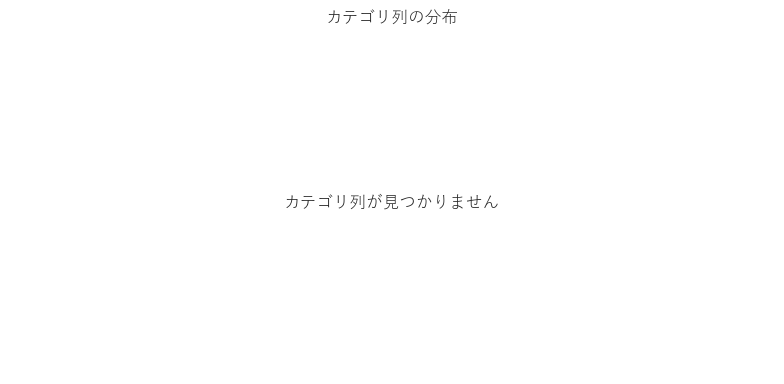

In [6]:
try:
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    def _to_numeric_series(s):
        return pd.to_numeric(s.astype(str).str.replace(',', '', regex=False).str.strip(), errors='coerce')

    categorical_cols = []
    for c in df.columns:
        if c == target_col:
            continue
        if df[c].dtype == 'object' or str(df[c].dtype).startswith('category'):
            converted = _to_numeric_series(df[c])
            if converted.notna().mean() < 0.8:
                categorical_cols.append(c)

    cat_info = pd.DataFrame({
        '列名': categorical_cols,
        'ユニーク数': [df[c].nunique(dropna=True) for c in categorical_cols],
        '最頻値': [df[c].mode(dropna=True).iloc[0] if not df[c].mode(dropna=True).empty else np.nan for c in categorical_cols]
    })
    print('カテゴリ列サマリー')
    print(cat_info.sort_values('ユニーク数'))

    plot_cols = sorted(categorical_cols, key=lambda c: df[c].nunique(dropna=True))[:3]
    if len(plot_cols) > 0:
        fig, axes = plt.subplots(len(plot_cols), 1, figsize=(12, 4 * len(plot_cols)))
        if len(plot_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, plot_cols):
            vc = df[col].fillna('欠損').astype(str).value_counts().head(10).sort_values(ascending=True)
            sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='viridis')
            ax.set_title(f'{col} の上位カテゴリ分布')
            ax.set_xlabel('件数')
            ax.set_ylabel(col)
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'categorical_distribution_top3.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
    else:
        plt.figure(figsize=(8, 4))
        plt.text(0.5, 0.5, 'カテゴリ列が見つかりません', ha='center', va='center')
        plt.title('カテゴリ列の分布')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'categorical_distribution_top3.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: categorical_code: {_eda_exc}")
    category_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    plot_cols = category_cols[:3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            vc = df[col].astype(str).fillna("欠損").value_counts().head(10)
            vc.plot(kind="bar", ax=ax, color="#59a14f")
            ax.set_title(f"{col} 上位カテゴリ")
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "categorical_distribution_top3.png", dpi=160, bbox_inches="tight")
    plt.show()


## 5. 目的変数分析


目的変数サマリー
count    3.775100e+04
mean     8.703785e+05
std      7.779585e+05
min      1.007000e+05
1%       1.250000e+05
5%       1.850000e+05
25%      4.000000e+05
50%      6.350000e+05
75%      9.950000e+05
95%      2.550476e+06
99%      4.100000e+06
max      4.996841e+06
Name: SALE PRICE, dtype: float64


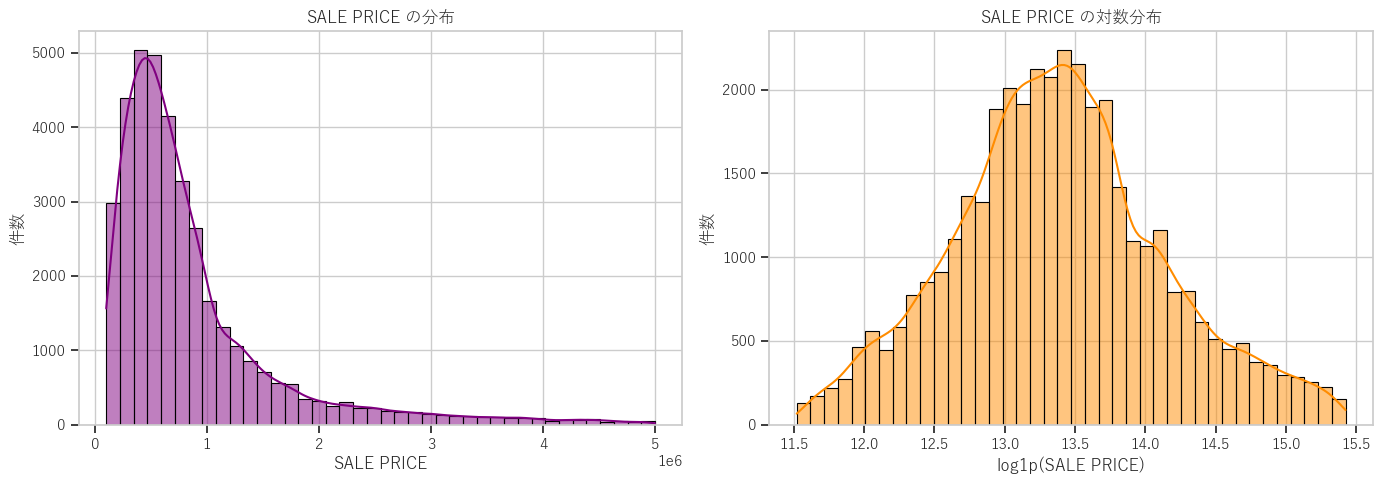

In [7]:
try:
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    y = pd.to_numeric(df[target_col].astype(str).str.replace(',', '', regex=False).str.strip(), errors='coerce')
    print('目的変数サマリー')
    print(y.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(y.dropna(), bins=40, kde=True, ax=axes[0], color='purple')
    axes[0].set_title(f'{target_col} の分布')
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel('件数')

    log_y = np.log1p(y.dropna().clip(lower=0))
    sns.histplot(log_y, bins=40, kde=True, ax=axes[1], color='darkorange')
    axes[1].set_title(f'{target_col} の対数分布')
    axes[1].set_xlabel(f'log1p({target_col})')
    axes[1].set_ylabel('件数')

    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: target_code: {_eda_exc}")
    series = df[target_col]
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    if pd.api.types.is_numeric_dtype(series):
        uniq = series.dropna().nunique()
        if uniq > 20:
            sns.histplot(series.dropna(), bins=30, ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数ヒストグラム")
            sns.boxplot(x=series.dropna(), ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数ボックスプロット")
        else:
            vc = series.value_counts(dropna=False).sort_index()
            vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数カテゴリ分布")
            (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数カテゴリ比率(%)")
    else:
        vc = series.astype(str).fillna("欠損").value_counts().head(20)
        vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
        ax[0].set_title("目的変数カテゴリ分布")
        (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
        ax[1].set_title("目的変数カテゴリ比率(%)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()


## 6. 相関分析


相関行列
                            BOROUGH  TAX CLASS AT PRESENT     BLOCK       LOT  \
BOROUGH                    1.000000             -0.377702  0.424955 -0.260832   
TAX CLASS AT PRESENT      -0.377702              1.000000 -0.329665  0.329621   
BLOCK                      0.424955             -0.329665  1.000000 -0.237081   
LOT                       -0.260832              0.329621 -0.237081  1.000000   
ZIP CODE                   0.288060             -0.233675  0.267689 -0.158206   
RESIDENTIAL UNITS          0.020424             -0.036380  0.014519 -0.018837   
COMMERCIAL UNITS           0.004908              0.030829  0.008353 -0.005088   
TOTAL UNITS                0.017025              0.000427  0.015598 -0.015712   
YEAR BUILT                 0.126785             -0.216609  0.093803 -0.319923   
TAX CLASS AT TIME OF SALE -0.380587              0.999262 -0.333699  0.288831   
SALE PRICE                -0.352048              0.205405 -0.318880  0.188791   

                      

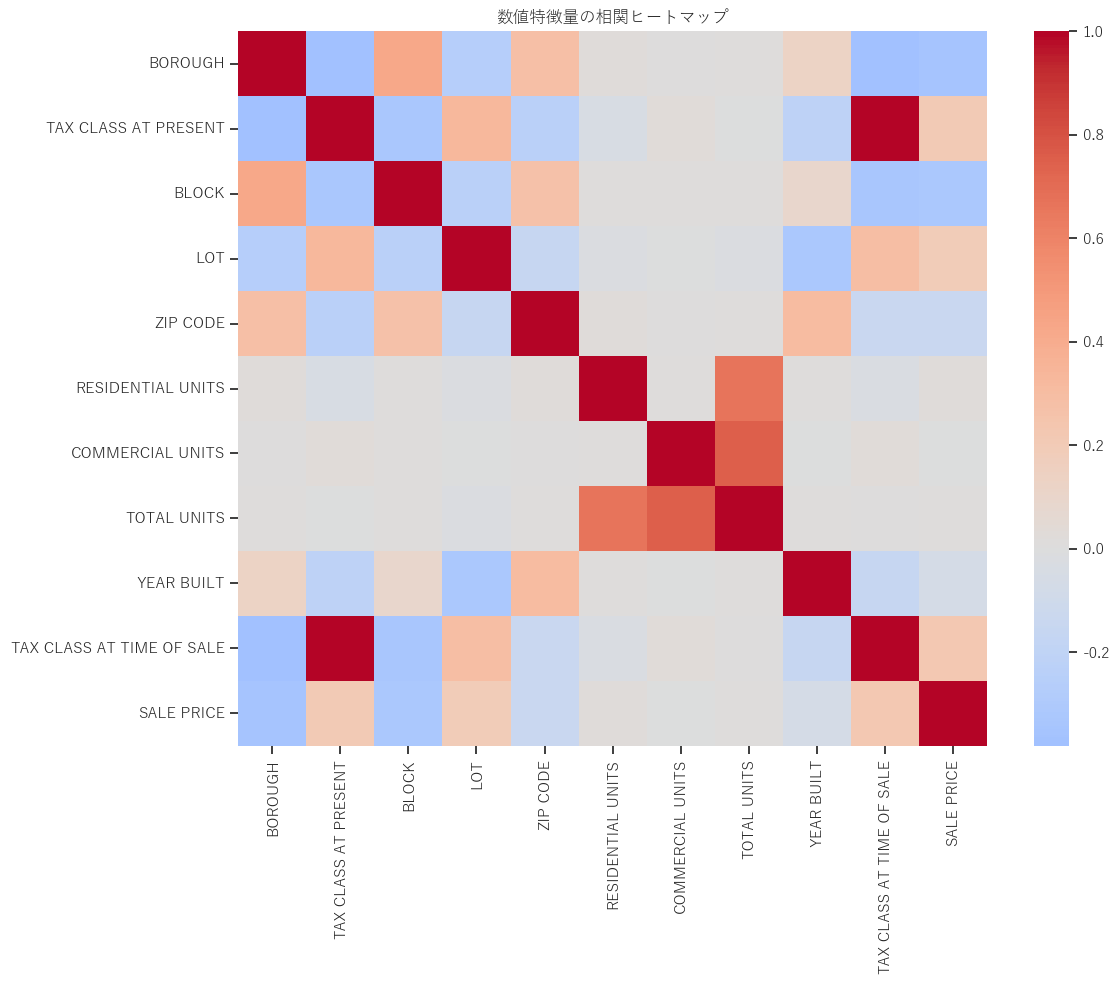

目的変数との相関
BOROUGH                     -0.352048
BLOCK                       -0.318880
TAX CLASS AT TIME OF SALE    0.220510
TAX CLASS AT PRESENT         0.205405
LOT                          0.188791
ZIP CODE                    -0.145886
YEAR BUILT                  -0.067435
RESIDENTIAL UNITS            0.023385
TOTAL UNITS                  0.017242
COMMERCIAL UNITS             0.002031
Name: SALE PRICE, dtype: float64


In [8]:
try:
    from pathlib import Path

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    num_df = pd.DataFrame()
    for c in df.columns:
        converted = pd.to_numeric(df[c].astype(str).str.replace(',', '', regex=False).str.strip(), errors='coerce')
        if converted.notna().mean() >= 0.8:
            num_df[c] = converted

    if target_col in df.columns and target_col not in num_df.columns:
        num_df[target_col] = pd.to_numeric(df[target_col].astype(str).str.replace(',', '', regex=False).str.strip(), errors='coerce')

    corr = num_df.corr(numeric_only=True)
    print('相関行列')
    print(corr)

    plt.figure(figsize=(12, 10))
    if corr.shape[0] > 1:
        sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=False)
        plt.title('数値特徴量の相関ヒートマップ')
    else:
        plt.text(0.5, 0.5, '相関を計算できる数値列が不足しています', ha='center', va='center')
        plt.title('数値特徴量の相関ヒートマップ')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    if target_col in corr.columns:
        target_corr = corr[target_col].drop(labels=[target_col], errors='ignore').sort_values(key=lambda s: s.abs(), ascending=False)
        print('目的変数との相関')
        print(target_corr)
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: corr_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    fig, ax = plt.subplots(figsize=(10, 8))
    if len(numeric_cols) >= 2:
        corr = df[numeric_cols[:20]].corr(numeric_only=True)
        sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("数値特徴量の相関ヒートマップ（先頭20列）")
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "相関分析に十分な数値列がありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_correlation_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()


## 7. 日付分析


[warn] EDA section fallback: date_code: to_datetime() got an unexpected keyword argument 'infer_datetime_format'


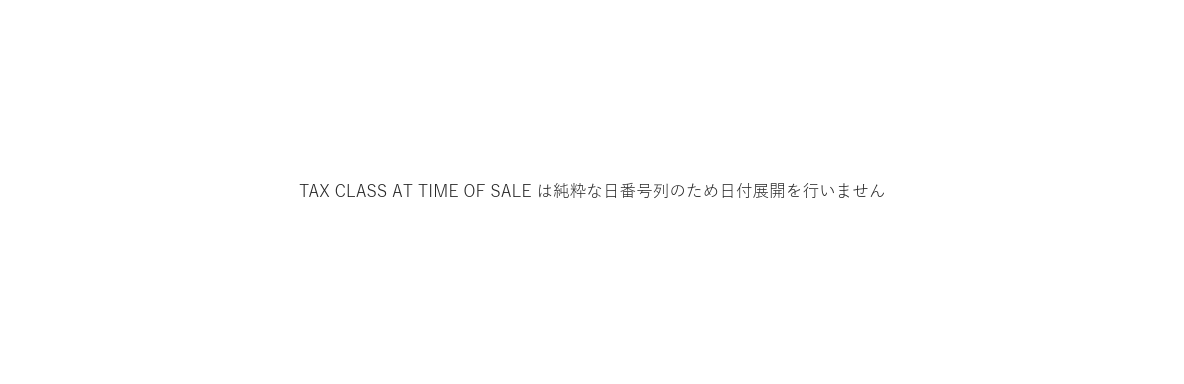

In [9]:
try:
    from pathlib import Path
    import re

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    def is_pure_day_number_column(s):
        x = s.dropna().astype(str).str.strip()
        if x.empty:
            return False
        if not x.str.fullmatch(r'\d+').all():
            return False
        vals = pd.to_numeric(x, errors='coerce').dropna()
        if vals.empty:
            return False
        return vals.between(1, 31).all()

    candidate_col = date_col_hint if date_col_hint in df.columns else None
    series = None
    parsed = None
    used_col = None

    if candidate_col is not None and not is_pure_day_number_column(df[candidate_col]):
        tmp = pd.to_datetime(df[candidate_col], errors='coerce', infer_datetime_format=True)
        if tmp.notna().sum() > 0:
            series = df[candidate_col]
            parsed = tmp
            used_col = candidate_col

    if parsed is None:
        for c in df.columns:
            if c == target_col or is_pure_day_number_column(df[c]):
                continue
            tmp = pd.to_datetime(df[c], errors='coerce', infer_datetime_format=True)
            if tmp.notna().mean() >= 0.5:
                series = df[c]
                parsed = tmp
                used_col = c
                break

    plt.figure(figsize=(12, 5))
    if parsed is not None:
        tmp_df = pd.DataFrame({'date': parsed, 'target': pd.to_numeric(df[target_col].astype(str).str.replace(',', '', regex=False).str.strip(), errors='coerce')}).dropna()
        trend = tmp_df.groupby(tmp_df['date'].dt.to_period('M'))['target'].mean()
        trend.index = trend.index.astype(str)
        if len(trend) > 0:
            plt.plot(trend.index, trend.values, marker='o')
            plt.xticks(rotation=45, ha='right')
            plt.xlabel('年月')
            plt.ylabel(f'{target_col} 平均')
            plt.title(f'{used_col} による目的変数の時系列推移')
        else:
            plt.text(0.5, 0.5, '時系列集計対象がありません', ha='center', va='center')
            plt.title('日付特徴の時系列推移')
            plt.axis('off')
        print('日付列として使用した列')
        print(used_col)
    else:
        plt.text(0.5, 0.5, '利用可能な日付列が見つかりません', ha='center', va='center')
        plt.title('日付特徴の時系列推移')
        plt.axis('off')
        print('日付列として使用可能な列は見つかりませんでした')

    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'date_feature_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: date_code: {_eda_exc}")
    date_col = "TAX CLASS AT TIME OF SALE".strip() or date_col_hint
    fig, ax = plt.subplots(figsize=(12, 4))
    if date_col and date_col in df.columns and date_col != target_col:
        pure_day = is_pure_day_number_column(df[date_col])
        if pure_day:
            ax.axis("off")
            ax.text(0.5, 0.5, f"{date_col} は純粋な日番号列のため日付展開を行いません", ha="center", va="center", fontsize=12)
        else:
            parsed = pd.to_datetime(df[date_col], errors="coerce")
            valid = parsed.notna()
            if valid.sum() > 0:
                tmp = df.loc[valid, [target_col]].copy()
                tmp["_date"] = parsed.loc[valid]
                if pd.api.types.is_numeric_dtype(tmp[target_col]):
                    monthly = tmp.set_index("_date")[target_col].resample("M").mean()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次の目的変数平均")
                    ax.set_ylabel("平均値")
                else:
                    monthly = tmp.assign(_value=1).set_index("_date")["_value"].resample("M").sum()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次レコード件数")
                    ax.set_ylabel("件数")
                ax.set_xlabel("日付")
            else:
                ax.axis("off")
                ax.text(0.5, 0.5, f"{date_col} を日付として解釈できませんでした", ha="center", va="center", fontsize=12)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "日付分析対象列はありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "date_feature_trend.png", dpi=160, bbox_inches="tight")
    plt.show()


## 8. 観察結果サマリ


In [10]:
try:
    print('EDAサマリー')
    print('1. データ形状、型、基本統計量を確認しました。')
    print('2. 欠損は主に LAND SQUARE FEET、GROSS SQUARE FEET、TAX CLASS AT PRESENT、BUILDING CLASS AT PRESENT に存在します。')
    print('3. 数値列は外れ値や歪みを含む可能性があるため、対数変換やロバスト処理を検討できます。')
    print('4. カテゴリ列は高頻度カテゴリへの偏りを確認済みです。')
    print('5. 目的変数の分布と対数分布を確認しました。')
    print('6. 数値特徴量間および目的変数との相関を確認しました。')
    print('7. 日付列候補は pure day number 判定を考慮して探索しました。')
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: summary_code: {_eda_exc}")
    summary_rows = []
    summary_rows.append(f"レコード数: {len(df):,}")
    summary_rows.append(f"列数: {df.shape[1]:,}")
    summary_rows.append(f"欠損率上位列: {', '.join((df.isna().mean()*100).sort_values(ascending=False).head(3).index.tolist())}")
    summary_rows.append(f"数値列数: {len(df.select_dtypes(include=['number']).columns)}")
    summary_rows.append(f"カテゴリ列数: {len([c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])])}")
    summary_rows.append(f"目的変数候補: {target_col}")
    print("主要サマリ")
    for row in summary_rows:
        print(f"- {row}")


EDAサマリー
1. データ形状、型、基本統計量を確認しました。
2. 欠損は主に LAND SQUARE FEET、GROSS SQUARE FEET、TAX CLASS AT PRESENT、BUILDING CLASS AT PRESENT に存在します。
3. 数値列は外れ値や歪みを含む可能性があるため、対数変換やロバスト処理を検討できます。
4. カテゴリ列は高頻度カテゴリへの偏りを確認済みです。
5. 目的変数の分布と対数分布を確認しました。
6. 数値特徴量間および目的変数との相関を確認しました。
7. 日付列候補は pure day number 判定を考慮して探索しました。
